In [2]:
from huggingface_hub import login
from transformers import AutoTokenizer
from dotenv import load_dotenv
import os

In [3]:
load_dotenv(override=True)
hf_token = os.getenv("HF_TOKEN")

if hf_token:
    print(f"Token exists and starts with {hf_token[:10]}")

Token exists and starts with hf_fmBSbXJ


In [5]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-Coder-7B-Instruct', trust_remote_code=True)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
text = "I am a student self-studying Deep Learning and LLM Engineering"
tokens = tokenizer.encode(text)
tokens

[40,
 1079,
 264,
 5458,
 656,
 5477,
 661,
 7024,
 18183,
 20909,
 323,
 444,
 10994,
 16595]

In [11]:
character_count = len(text)
word_count = len(text.split(' '))
token_count = len(tokens)
print(f"There are {character_count} characters, {word_count} words and {token_count} tokens")

There are 62 characters, 10 words and 14 tokens


In [12]:
tokenizer.decode(tokens)

'I am a student self-studying Deep Learning and LLM Engineering'

In [13]:
tokenizer.batch_decode(tokens)

['I am a student self-studying Deep Learning and LLM Engineering']

In [14]:
tokenizer.get_added_vocab()

{'<|endoftext|>': 151643,
 '<|im_start|>': 151644,
 '<|im_end|>': 151645,
 '<|object_ref_start|>': 151646,
 '<|object_ref_end|>': 151647,
 '<|box_start|>': 151648,
 '<|box_end|>': 151649,
 '<|quad_start|>': 151650,
 '<|quad_end|>': 151651,
 '<|vision_start|>': 151652,
 '<|vision_end|>': 151653,
 '<|vision_pad|>': 151654,
 '<|image_pad|>': 151655,
 '<|video_pad|>': 151656,
 '<tool_call>': 151657,
 '</tool_call>': 151658,
 '<|fim_prefix|>': 151659,
 '<|fim_middle|>': 151660,
 '<|fim_suffix|>': 151661,
 '<|fim_pad|>': 151662,
 '<|repo_name|>': 151663,
 '<|file_sep|>': 151664}

In [15]:
len(tokenizer.vocab)

151665

In [16]:
messages = [
    {"role": "system", "content": "You are a helpful assistant"},
    {"role": "user", "content": "Tell a light-hearted joke for a room of Data Scientists"}
  ]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(prompt)

<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Tell a light-hearted joke for a room of Data Scientists<|im_end|>
<|im_start|>assistant



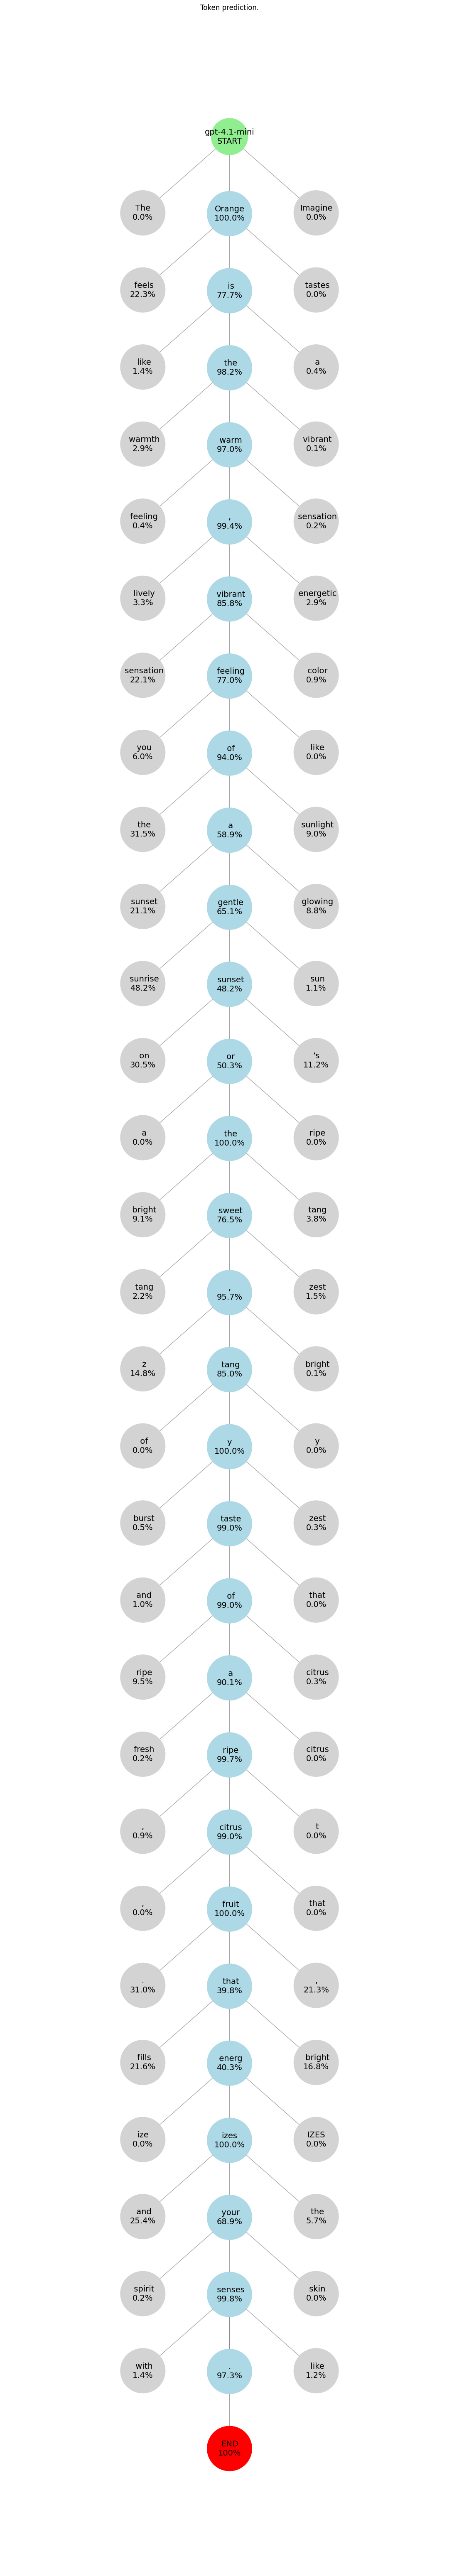

In [17]:
from visualizer import TokenPredictor, create_token_graph, visualize_predictions

message = "In one sentence, describe the color orange to someone who has never been able to see"
model_name = "gpt-4.1-mini"

predictor = TokenPredictor(model_name)
predictions = predictor.predict_tokens(message)
G = create_token_graph(model_name, predictions)
plt = visualize_predictions(G)
plt.show()